## Preliminaries

dtype('uint8')

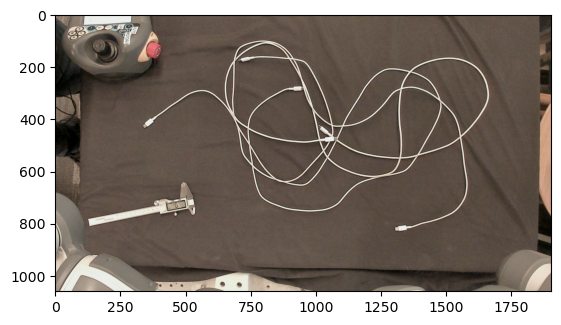

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240730-152135.png")
im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240711-132710.png")
# im_frame2 = Image.open("/home/justinyu/vsumedh/data/raw_images/parallel-20240711-124446.png")

np_frame2 = np.array(im_frame2)
plt.imshow(np_frame2)

np_frame2.dtype

In [2]:
print(np_frame2.shape)
np_frame2 = np_frame2[:, 0:1800,:]


(1060, 1904, 3)


(1060, 1800, 3)


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride
/home/mallika/anaconda3/envs/vsumedh-lipnew-tangential/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Endpoint detection took 2.6797714233398438 seconds


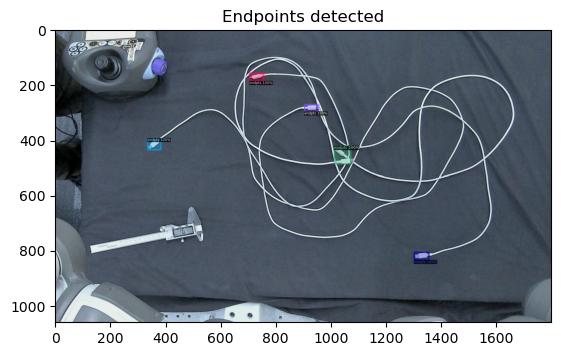

(1060, 1800, 3)
[[ 174  732]
 [ 821 1330]
 [ 415  359]
 [ 455 1042]
 [ 285  930]]


<Figure size 640x480 with 0 Axes>

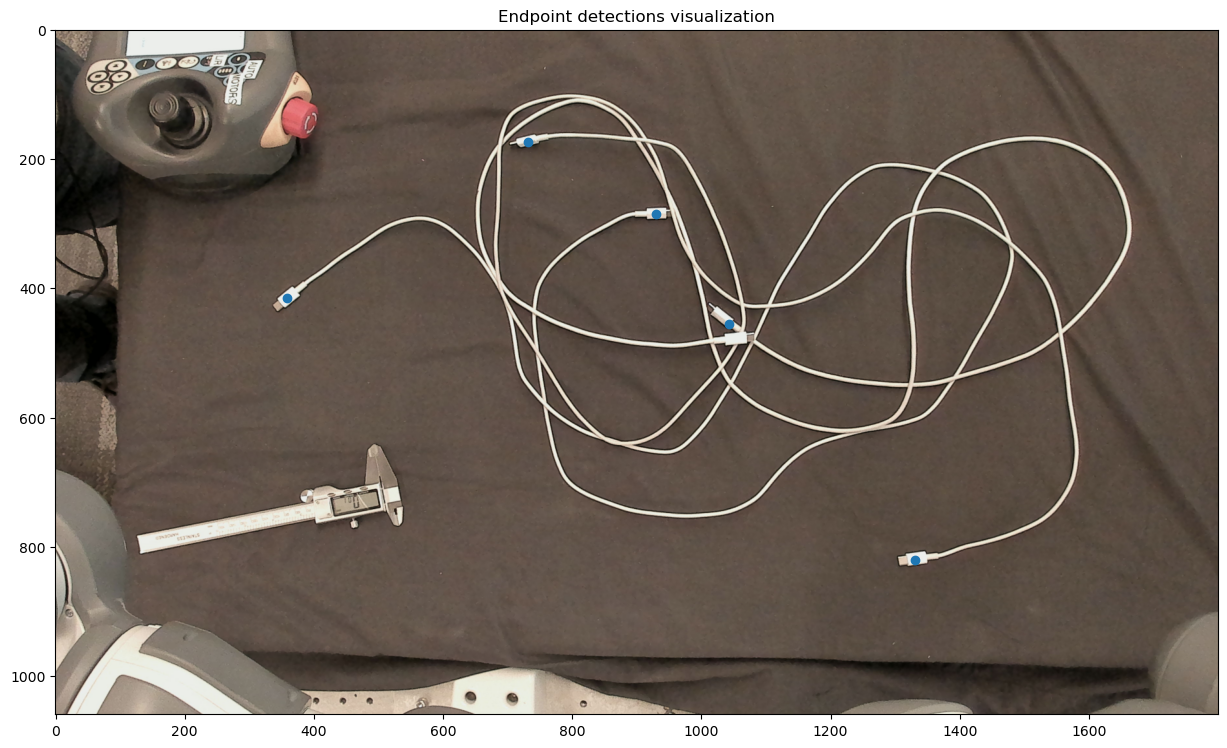

In [3]:
img = np_frame2

import numpy as np 
import time
from decluttering.data.detectron2_repo import analysis as loop_detectron

def get_endpoints(img):
    endpoint_start = time.time()
    endpoint_boxes, out_viz = loop_detectron.predict(img, thresh=0.99, endpoints=True)
    endpoint_end = time.time()
    print("Endpoint detection took {} seconds".format(endpoint_end - endpoint_start))
    plt.clf()
    plt.imshow(out_viz)
    plt.title("Endpoints detected")
    plt.show()
    plt.imsave("/home/justinyu/multicable-decluttering/misc_images/endpoints_detected.png", out_viz)
    print(out_viz.shape)

    endpoints = []
    for i, box in enumerate(endpoint_boxes):
        xmin, ymin, xmax, ymax = box
        x = (xmin + xmax)/2
        y = (ymin + ymax)/2
        endpoints.append([y, x])   
    endpoints = np.array(endpoints).astype(np.int32)
    print(endpoints)

    plt.clf()
    plt.figure(figsize=(15,18))
    plt.title("Endpoint detections visualization")
    plt.imshow(img)
    if len(endpoints) > 0:
        plt.scatter(endpoints[:, 1], endpoints[:, 0])
    plt.show()
    return endpoints

print(img.shape)
endpts = get_endpoints(img)

/home/mallika/anaconda3/envs/vsumedh-lipnew-tangential/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Loading pretrained CLIP
Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy
Inference time:  0.07686281204223633
Number of masks before filtering torch.Size([8, 1, 1060, 1800])
Area of masks before filtering tensor([17065, 14056,  2734, 78439,  3137,   208,    91,   225],
       device='cuda:0')
torch.Size([3, 1, 1060, 1800])


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


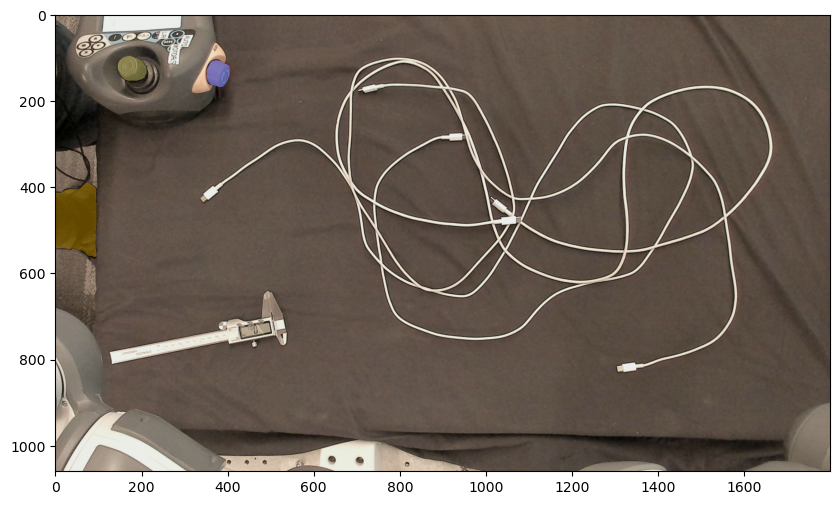

In [4]:
from decluttering.data.utils.detic_dataloader import DeticDataloader

detic = DeticDataloader()
detic.create()
detic.default_vocab()
out = detic.predict(np_frame2)
import torch
num_masks = out['masks'].shape[0]
print("Number of masks before filtering", out['masks'].shape)
print("Area of masks before filtering", torch.sum(out['masks'], dim = (1,2,3)))

def filter_mask_by_area(masks, max_area = 17000, min_area = 500):
    """
    Filter masks by area
    """
    mask_areas = torch.sum(masks, dim = (1,2,3))
    mask_areas = mask_areas.cpu().numpy()
    mask_areas = mask_areas.reshape(-1)
    masks_filtered = masks[(mask_areas < max_area) & (min_area < mask_areas)]
    return masks_filtered

filtered_areas = filter_mask_by_area(out['masks'])
print(filtered_areas.shape)
num_masks = filtered_areas.shape[0]

starting_block = filter_mask_by_area(out['masks'], max_area = 24000, min_area = 17000)
detic.visualize_output(np_frame2, filtered_areas, image_save_path=f"detic_masks/filtered_masks{time}.png")

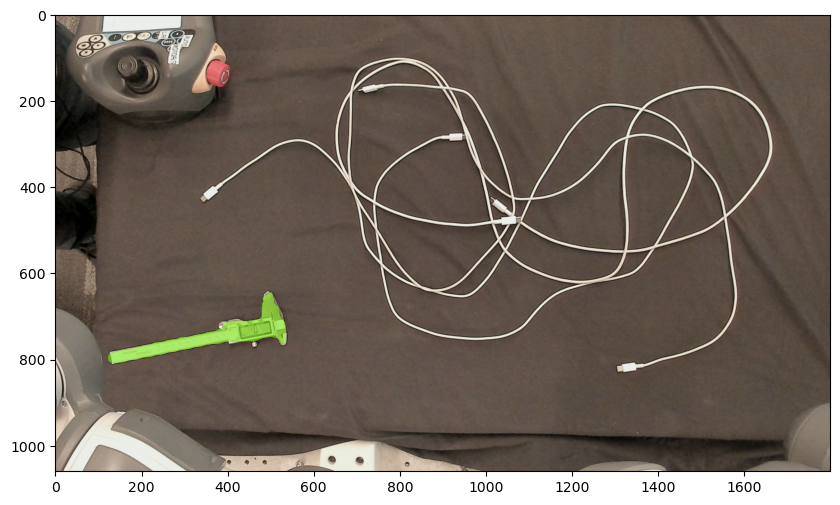

In [5]:
detic.visualize_output(np_frame2, starting_block)

In [6]:
from decluttering.data.tracer.analytic_tracer.simple_uncertain_trace_single import trace

def analytic_tracer(img, point, keepout_mask=None):
        # trace from endpoint on image
        path, finished_paths = trace(img, point, exact_path_len=3, viz=False, keepout_mask=keepout_mask)
        agree_point = tuple(np.array([point[0], point[1]]).astype(np.int32))
        if path is None:
            if len(finished_paths) > 0:
                min_len_path = float('inf')
                for fp in finished_paths:
                    if len(fp) < min_len_path:
                        min_len_path = len(fp)
                for i in range(min_len_path):
                    values = np.array([list(fp[i]) for fp in finished_paths])
                    x = values[:, 0]
                    y = values[:, 1]
                    x_diff = np.max(x)-np.min(x)
                    y_diff = np.max(y)-np.min(y)
                    if x_diff < 5 and y_diff < 5:
                        agree_point = values[0]
            return agree_point, True
        return path, False

## Divergence

In [7]:
from collections import OrderedDict

def visualize_trace_solid_color(img, path, black=False, color=None):
    img = img.copy()
    for i in range(len(path) - 1):        
        # if path is ordered dict, use below logic
        if not isinstance(path, OrderedDict):
            pt1 = tuple(path[i].astype(int))
            pt2 = tuple(path[i+1].astype(int))
        else:
            path_keys = list(path.keys())
            pt1 = path_keys[i]
            pt2 = path_keys[i + 1]
        # print(color_for_pct(i/len(path)))

        cv2.line(img, pt1[::-1], pt2[::-1], color, 2 if not black else 5)
    return img

In [8]:
from skimage.morphology import skeletonize

def isolated_comb_binary_skeleton(colored_mask):
    grayscale = cv2.cvtColor(colored_mask, cv2.COLOR_RGB2GRAY)
    
    _, layered_thresh = cv2.threshold(grayscale, 100, 255, cv2.THRESH_TOZERO_INV)    # 100 hardcoded
    skel_img = skeletonize(layered_thresh, method = "lee")

    # convert to binary image
    bin_img = skel_img // 28   # 28 hardcoded
    
    return bin_img

In [9]:
from scipy.ndimage import convolve

def find_points_of_interest(bin_skel):
    kernel = np.array([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]])

    neighbor_sum = convolve(bin_skel, kernel, mode='constant')

    # if 1 in center of 3x3, sums up all neighbors including center pixel, for each pixel on image
    middle_ones_neighbor_sum = np.multiply(neighbor_sum, bin_skel) 

    points_of_interest = np.flip(np.argwhere(middle_ones_neighbor_sum == 2), axis = 1)

    return points_of_interest

In [10]:
def div_points_from_mask(pts_of_interest, endpts):

    divergence_pts = np.empty([0, 2])

    for poi in pts_of_interest:
        close_to_endpt = False
        for glob_endpt in np.flip(endpts, axis = 1):
            if np.linalg.norm(glob_endpt - poi) <= 20:
                close_to_endpt = True
        if not close_to_endpt:
            divergence_pts = np.append(divergence_pts, np.array([poi]), axis=0)
    
    return divergence_pts

In [11]:
from decluttering.data.tracer.tusk_pipeline.tracer import Tracer
from decluttering.data.utils.tracer_dataloader import TracerDataloader
from decluttering.data.tracer.tusk_pipeline.tracer import TraceEnd

def get_trace_list(endpts):
    trace_list = []
    endpoint_cond_table = []

    for endpt in range(len(endpts)):

        # print("ON ENDPOINT: " + str(np.array(endpts[endpt])))
        print("ON ENDPOINT: " + str(endpt))

        starting_pixels = analytic_tracer(img, np.array(endpts[endpt]), keepout_mask=None)
        tracer = TracerDataloader()

        out = tracer.predict(img, np.asarray(starting_pixels[0]).astype(int), endpoints=endpts)
        trace_path = out["trace"]
        trace_end = out["trace_end"]
        final_endpoint = out["endpoint"]
        # print(f"{final_endpoint = }")
        # print(f"{out.keys() = }")
        # print(out["endpoint"])
        trace_list.append(trace_path)
            
        if trace_end == TraceEnd.ENDPOINT:
            # print(f"{endpts = }")
            # print(f"{trace_path = }")
            # print(f"{trace_path[-1] = }")
            endpoint_cond_table.append([endpt, np.nonzero(np.all(endpts == final_endpoint, axis = 1))[0][0]])
        elif trace_end == TraceEnd.FINISHED or trace_end == TraceEnd.RETRACE:
            print(f"TRACE END for endpoint {endpt} = " + str(trace_end))
            endpoint_cond_table.append([endpt, -1])
        elif trace_end == TraceEnd.EDGE:
            pass # perform edge IP maneuver?

    return trace_list, endpoint_cond_table

In [12]:
traces, ect = get_trace_list(endpts)
print(ect)
print(traces)

ON ENDPOINT: 0
Autoregressive Tracer Using GPU
Beginning trace with 4 start points


Elapsed time for tracing:  1.0578155517578125
ON ENDPOINT: 1
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  2.0508434772491455
ON ENDPOINT: 2
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  0.8972527980804443
ON ENDPOINT: 3
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  0.9002175331115723
TRACE END for endpoint 3 = TraceEnd.RETRACE
ON ENDPOINT: 4
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  1.8452990055084229
[[0, 2], [1, 0], [2, 0], [3, -1], [4, 3]]
[array([[ 174,  732],
       [ 169,  759],
       [ 164,  786],
       [ 162,  814],
       [ 164,  828],
       [ 165,  843],
       [ 166,  857],
       [ 167,  871],
       [ 168,  885],
       [ 170,  899],
       [ 172,  913],
       [ 174,  927],
       [ 176,  941],
       [ 181,  954],
       [ 190,  966],
       [ 201,  975],
       [ 212,  

In [13]:
# divergence function takes in a pair of endpoints, generates layered mask, and returns points of divergence

def divergence_points(ep_idx_1, ep_idx_2, trace_list):
    CYAN_COLOR = (52, 205, 235)
    MAGENTA_COLOR = (235, 52, 177)

    div_points = np.empty([0, 2])

    trace_1, trace_2 = trace_list[ep_idx_1], trace_list[ep_idx_2]

    mask_1 = visualize_trace_solid_color(np.zeros(img.shape, dtype=np.uint8), trace_1, color = CYAN_COLOR, black = True)
    mask_2 = visualize_trace_solid_color(np.zeros(img.shape, dtype=np.uint8), trace_2, color = MAGENTA_COLOR, black = True)
    layered_mask = mask_1 + mask_2
    bin_skel_img = isolated_comb_binary_skeleton(layered_mask)
    points_of_interest = find_points_of_interest(bin_skel_img)
    div_points_from_mask_list = np.array(div_points_from_mask(points_of_interest, endpts))

    div_points = np.append(div_points, div_points_from_mask_list, axis=0)
        
    return div_points

In [14]:
def divergence_points_viz(ep_idx_1, ep_idx_2, trace_list):
    CYAN_COLOR = (52, 205, 235)
    MAGENTA_COLOR = (235, 52, 177)

    div_points = np.empty([0, 2])

    trace_1, trace_2 = trace_list[ep_idx_1], trace_list[ep_idx_2]

    mask_1 = visualize_trace_solid_color(np.zeros(img.shape, dtype=np.uint8), trace_1, color = CYAN_COLOR, black = True)
    mask_2 = visualize_trace_solid_color(np.zeros(img.shape, dtype=np.uint8), trace_2, color = MAGENTA_COLOR, black = True)
    layered_mask = mask_1 + mask_2
    bin_skel_img = isolated_comb_binary_skeleton(layered_mask)
    points_of_interest = find_points_of_interest(bin_skel_img)
    div_points_from_mask_list = np.array(div_points_from_mask(points_of_interest, endpts))
    plt.imshow(layered_mask)
    plt.scatter(div_points_from_mask_list.T[0], div_points_from_mask_list.T[1])
    plt.show()

    div_points = np.append(div_points, div_points_from_mask_list, axis=0)
        
    return div_points

In [15]:
def all_div_points(endpts):
    trace_list, table = get_trace_list(endpts)
    # filter by removing correlated endpts (ex (0, 1), (1, 0))
    filtered_table = list(filter(lambda ep_pair: ep_pair[::-1] not in table, table))
    print(f"{table = }")
    print(f"{filtered_table = }")

    all_div_points = []
    for start_idx, ep_idx_2 in filtered_table:
        # check to see if any end indices match start_dx in filtered_table
        for ep_idx_1, end_idx in filtered_table:
            if start_idx == end_idx:
                print("PERFORMING DIVERGENCE ANALYSIS ON: " + str((start_idx, ep_idx_1)))
                div_points = divergence_points(start_idx, ep_idx_1, trace_list)
                divergence_points_viz(start_idx, ep_idx_1, trace_list)
                # TODO: perform IP maneuver on each of the div_points?
                all_div_points.append(div_points)
    
    print("RETURNING " + str(all_div_points))
    return all_div_points
    

ON ENDPOINT: 0
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  1.0785396099090576
ON ENDPOINT: 1
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  2.084530830383301
ON ENDPOINT: 2
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  0.8767790794372559
ON ENDPOINT: 3
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  0.9985790252685547
TRACE END for endpoint 3 = TraceEnd.RETRACE
ON ENDPOINT: 4
Autoregressive Tracer Using GPU
Beginning trace with 4 start points
Elapsed time for tracing:  1.8737430572509766
table = [[0, 2], [1, 0], [2, 0], [3, -1], [4, 3]]
filtered_table = [[1, 0], [3, -1], [4, 3]]
PERFORMING DIVERGENCE ANALYSIS ON: (3, 4)


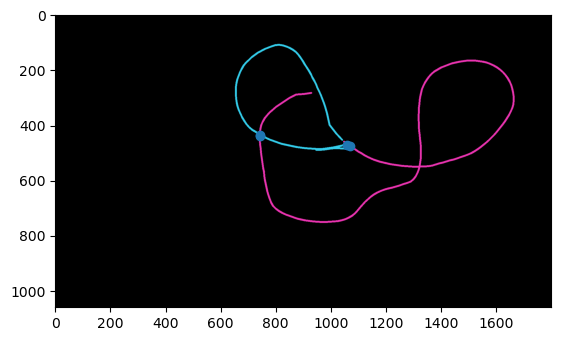

RETURNING [array([[ 742.,  436.],
       [ 744.,  437.],
       [1060.,  471.],
       [1071.,  473.]])]


In [25]:
x = all_div_points(endpts)    

## Scratch

In [29]:
print(x)
for j in x:
    print(j)

[array([[ 742.,  436.],
       [ 744.,  437.],
       [1060.,  471.],
       [1071.,  473.]])]
[[ 742.  436.]
 [ 744.  437.]
 [1060.  471.]
 [1071.  473.]]


In [17]:
# print(endpts)
# from numpy import all
# np.all(np.nonzero(endpts == [603, 1510]))
# np.nonzero(np.all(endpts == [603, 1510], axis = 1))[0][0]

In [18]:
t = [[0, 1], [1,0], [2,-1], [2, 1], [3,2], [1, 2]]
list(filter(lambda ep_pair: ep_pair[::-1] not in t, t))

[[2, -1], [3, 2]]

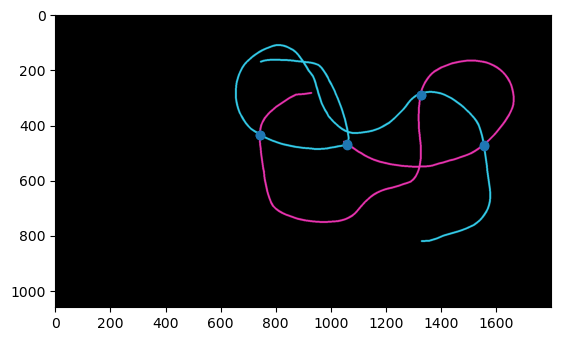

array([[1328.,  288.],
       [1326.,  289.],
       [ 742.,  435.],
       [ 743.,  436.],
       [1058.,  468.],
       [1058.,  470.],
       [1556.,  472.],
       [1555.,  473.]])

In [19]:


divergence_points_viz(1, 4, traces)

In [20]:
# from matplotlib import cm

# def divergence_points_modified_skel(ep_idx_1, ep_idx_2, trace_list):
#     CYAN_COLOR = (52, 205, 235)
#     MAGENTA_COLOR = (235, 52, 177)

#     div_points = np.empty([0, 2])

#     trace_1, trace_2 = trace_list[ep_idx_1], trace_list[ep_idx_2]

#     mask_1 = visualize_trace_solid_color(np.zeros(img.shape, dtype=np.uint8), trace_1, color = CYAN_COLOR, black = True)
#     mask_2 = visualize_trace_solid_color(np.zeros(img.shape, dtype=np.uint8), trace_2, color = MAGENTA_COLOR, black = True)
#     layered_mask = mask_1 + mask_2
#     bin_skel_img = isolated_comb_binary_skeleton(layered_mask)


#     num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(bin_skel_img, connectivity=8)
#     for i in range(1, num_labels):
#         x = stats[i, cv2.CC_STAT_LEFT]
#         y = stats[i, cv2.CC_STAT_TOP]
#         w = stats[i, cv2.CC_STAT_WIDTH]
#         h = stats[i, cv2.CC_STAT_HEIGHT]
#         area = stats[i, cv2.CC_STAT_AREA]
#         (cX, cY) = centroids[i]
#         output = bin_skel_img.copy()
#         cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 3)
#         cv2.circle(output, (int(cX), int(cY)), 4, (0, 0, 255), -1)
#         cv2.imshow("Output", output)
#         componentMask = (labels == i).astype("uint8") * 255
#         cv2.imshow("Connected Component", componentMask)
#         cv2.show()


#     plt.imshow(bin_skel_img, cmap=cm.bone)
#     plt.show()
#     print(num_labels)
#     print(labels_im)

#     # points_of_interest = find_points_of_interest(bin_skel_img)
#     # div_points_from_mask_list = np.array(div_points_from_mask(points_of_interest, endpts))
#     # plt.imshow(layered_mask)
#     # plt.scatter(div_points_from_mask_list.T[0], div_points_from_mask_list.T[1])
#     # plt.show()

#     # div_points = np.append(div_points, div_points_from_mask_list, axis=0)
        
#     # return div_points

# divergence_points_modified_skel(2, 3, traces)